### Imports, Hardware check

In [ ]:
using Pkg
Pkg.activate("../")
println("Current node: ", gethostname())
Base.Threads.nthreads()

In [2]:
using Random, Plots, StatsBase, JLD2, OMEinsum, SparseArrays, LinearAlgebra
using OhMyU1
using OhMyU1: ChargeIndex, U1MPS
using OhMyU1: sample_feasible_lp, sample_feasible_lp!, compute_link_charges, compute_site_charges, compute_indices, init_u1_mps, 
orthogonalize!, normalize!, TrainParams, boltzman_probability, train_nondeg!, sample_nondeg_parallel!, cost, u1_norm
using OhMyU1: diversify!, update_index!, graph_dist, random_bilinear_form, random_assignment_vector, fill_assignment_vectors_parallel!,
pick_best_samples, assignment_matrix, generate_random_matrix_vector, SolverParams, graph_dist_global, solve, get_mps, build_mps_from_feasible_samples,
OptimizationProblem, assert_feasible_lp, SolverStatistics, fill_assignment_vectors!
using Statistics, LaTeXStrings, HypothesisTests
using Base.Threads: @spawn
using JuMP, SCIP


SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


### Func tools

In [3]:
function get_res_vec(filename; strategy, n_sizes, problems_range, w=nothing)
    res = load(filename)["res_dict"][strategy]
    res_vec = []
    for n in n_sizes
        for i in problems_range
            if w == nothing
                push!(res_vec, res[n][i].c_min)
            else
                push!(res_vec, res[w][n][i].c_min)
            end
        end
    end
    return Float64.(res_vec)
end

get_res_vec (generic function with 1 method)

In [4]:
function detailed_wilcoxon(a::Vector{T}, b::Vector{T}; alpha=0.05) where T <: Number
    diffs = a .- b
    
    wins = count(x -> x > 0, diffs)   # a > b
    losses = count(x -> x < 0, diffs) # a < b
    ties = count(x -> x == 0, diffs)  # a == b
    n = length(diffs)
    
    test = SignedRankTest(a, b)
    p_val_right = pvalue(test, tail=:right)
    
    println("=== Wilcoxon Signed-Rank Detailed Report ===")
    println("Sample size (N): $n")
    println("Wins (a > b):   $wins ($(round(wins/n*100, digits=1))%)")
    println("Losses (a < b): $losses ($(round(losses/n*100, digits=1))%)")
    println("Ties (a == b):   $ties")
    println("-------------------------------------------")
    println("W-statistic:    $(test.W)")
    println("P-value (one-sided, a > b): $p_val_right")
    
    if p_val_right < alpha
        println("Result: b considerably LESS, than a (α=$alpha)")
    else
        println("Result: no observable difference")
    end
end

detailed_wilcoxon (generic function with 1 method)

In [5]:
function plot_abs_improvement(a, b; n=50, x=[12, 13, 14, 15, 16].^2)
    L = length(a)
    A_grouped = reshape(a, n, :)
    B_grouped = reshape(b, n, :)
    diff_grouped = A_grouped .- B_grouped

    boxplot(diff_grouped, 
            fillcolor = palette(:default)[1], 
            fillalpha = 0.8,
            whisker_range = 1.0,
            
            outliers = true,           
            markercolor = :black,     
            markersize = 4,            
            
            legend = false,
            title = "Absolute improvement",
            xlabel = "# Variables",
            ylabel = L"\Delta" * " Cost",
            x_ticks=(1:5, x)
    )
end

plot_abs_improvement (generic function with 1 method)

In [18]:
function plot_rel_improvement(a, b; n=50, x=[12, 13, 14, 15, 16].^2)
    L = length(a)
    A_grouped = reshape(a, n, :)
    B_grouped = reshape(b, n, :)
    rel_diff = (A_grouped .- B_grouped) ./ (abs.(A_grouped)) * 100

    boxplot(rel_diff, 
            fillcolor = palette(:default)[1], 
            fillalpha = 0.8,
            # whisker_range = 1.5,
            
            outliers = true,           
            markercolor = :black,     
            markersize = 4,            
            
            legend = false,
            xlabel = "# Variables",
            ylabel = L"\Delta" * " Cost, %",
            x_ticks=(1:5, x),
            ylims=(-20, 30)
    )
end

plot_rel_improvement (generic function with 1 method)

### AB Best Nonzero Mixed 0.4 VS Best Cost (Linear)

In [21]:
n_sizes = [12, 13, 14, 15, 16]
problems_range = 1:50
w_vec = [0.4]
path2_best_cost = "../data/test_random_assignment/res_best_cost_barrier_false_div_false_r=50.jld2"
best_cost_vec = get_res_vec(path2_best_cost, strategy="best_cost", n_sizes=n_sizes, problems_range=problems_range)
for w in w_vec
    path2_mixed = "../data/test_random_assignment/res_best nonzero mixed_barrier_false_div_false_r=50_w=0.4.jld2"
    println("\n w=$(w): ")
    best_cost_mixed = get_res_vec(path2_mixed, strategy="best nonzero mixed", n_sizes=n_sizes, problems_range=problems_range, w=w)
    detailed_wilcoxon(best_cost_vec, best_cost_mixed)
end


 w=0.4: 
=== Wilcoxon Signed-Rank Detailed Report ===
Sample size (N): 250
Wins (a > b):   179 (71.6%)
Losses (a < b): 54 (21.6%)
Ties (a == b):   17
-------------------------------------------
W-statistic:    23012.0
P-value (one-sided, a > b): 4.205953023457671e-20
Result: b considerably LESS, than a (α=0.05)


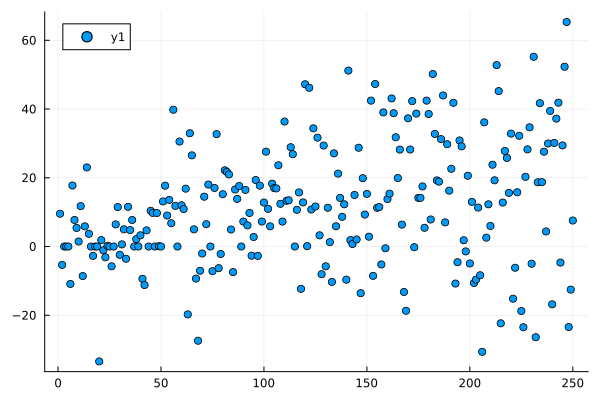

In [22]:
path2_mixed = "../data/test_random_assignment/res_best nonzero mixed_barrier_false_div_false_r=50_w=0.4.jld2"
get_b_vec = w -> get_res_vec(path2_mixed, strategy="best nonzero mixed", n_sizes=n_sizes, problems_range=problems_range, w=w)
for w in [0.4]
    p = scatter(best_cost_vec - get_b_vec(w))
    display(p)
end

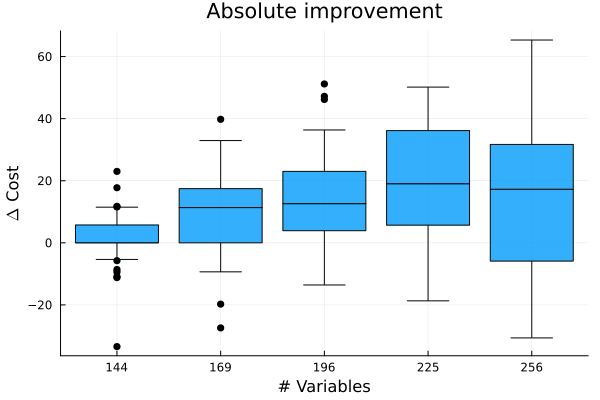

In [23]:
a = best_cost_vec
b = get_b_vec(0.4)
plot_abs_improvement(a, b)

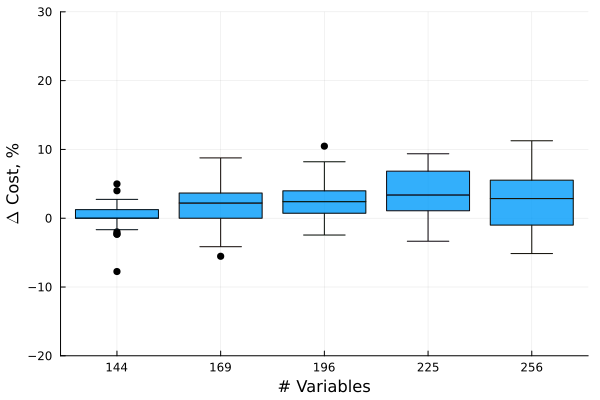

In [24]:
plot_rel_improvement(a, b)

In [25]:
savefig("pictures/test_Linear.png")

"d:\\Releases\\OhMyU1_public\\examples\\pictures\\test_Linear.png"

### AB Best Nonzero Mixed 0.4 VS Best Cost (Quadratic)

In [26]:
n_sizes = [12, 13, 14, 15, 16]
problems_range = 1:50
w_vec = [0.4]
path2_best_cost = "../data/test_random_assignment/res_best_cost_barrier_false_div_false_r=7_quadratic.jld2"
best_cost_vec = get_res_vec(path2_best_cost, strategy="best_cost", n_sizes=n_sizes, problems_range=problems_range)
for w in w_vec
    path2_mixed = "../data/test_random_assignment/res_best nonzero mixed_barrier_false_div_false_r=7_w=0.4_quadratic.jld2"
    println("\n w=$(w): ")
    best_cost_mixed = get_res_vec(path2_mixed, strategy="best nonzero mixed", n_sizes=n_sizes, problems_range=problems_range, w=w)
    detailed_wilcoxon(best_cost_vec, best_cost_mixed)
end


 w=0.4: 
=== Wilcoxon Signed-Rank Detailed Report ===
Sample size (N): 250
Wins (a > b):   171 (68.4%)
Losses (a < b): 73 (29.2%)
Ties (a == b):   6
-------------------------------------------
W-statistic:    22557.0
P-value (one-sided, a > b): 2.6605807032749445e-12
Result: b considerably LESS, than a (α=0.05)


In [31]:
print(minimum((a .- b) ./ abs.(a)), maximum((a .- b) ./ abs.(a)))

-0.175657030398180920.24124480804473017

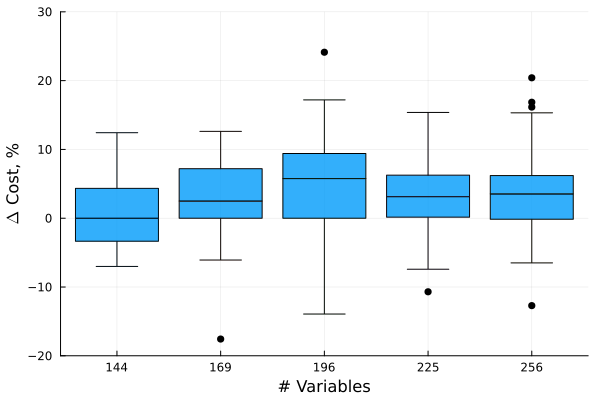

In [32]:
get_b_vec = w -> get_res_vec(path2_mixed, strategy="best nonzero mixed", n_sizes=n_sizes, problems_range=problems_range, w=w)
a = best_cost_vec
b = get_b_vec(0.4)
plot_rel_improvement(a, b)

In [33]:
savefig("pictures/test_Quadratic.png")

"d:\\Releases\\OhMyU1_public\\examples\\pictures\\test_Quadratic.png"